In [318]:
import numpy as np
from collections.abc import Callable
from numpy.typing import NDArray
import matplotlib.pyplot as plt
import scipy as sc
import typing
from typing import Optional

# In this notebook, I will attempt to replicate POD and hyperreduction for a nonparametric system

- Source: https://kiwi.oden.utexas.edu/papers/Parametric-model-reduction-survey-Benner-Gugercin-Willcox.pdf

## My Stepwise edits, before Codex cleans them up

In [319]:
##### Simple PDE class (PRE CHATGPT EDITS)

# class PDE():
#     def __init__(self,E, A, B, C, x0,dt,u):
#         self.E = E
#         self.A = A
#         self.B = B
#         self.x = x0
#         self.dt = dt
#         self.C = C
#         self.u = u
#         self.t = 0

#         self.states = []

#         self.preprocess()

#     def preprocess(self):
#         self.Einv = np.linalg.inv(self.E)

#     def update(self, saving = True, method = 'forward Euler'):
#         if saving:    self.states.append(self.x)

#         if method == 'forward Euler': self.step_FOM_forward_Euler()


    

#     def step_FOM_forward_Euler(self):
#         xdot = self.Einv @(self.A@self.x + self.B @ self.u(self.t))
#         self.x = self.x + xdot * self.dt
#         self.t += self.dt
    
#     def observe_FOM(self):
#         self.y = self.C @ self.x
        
    


In [320]:
#### Adding POD-Galerkin to the pde class


# class PDE:
#     """Finite-dimensional first-order PDE model E xdot = A x + B u(t)."""

#     def __init__(
#         self,
#         E: NDArray[np.float64],
#         A: NDArray[np.float64],
#         B: NDArray[np.float64],
#         C: NDArray[np.float64],
#         x0: NDArray[np.float64],
#         dt: float,
#         u: Callable[[float], NDArray[np.float64]],
#         Galerkin: bool = False,
#         V: Optional[NDArray[np.float64]] = None,
#     ) -> None:
#         """Create the model and validate all matrix and vector dimensions."""
#         self.E = self._as_float_array(E, "E")
#         self.A = self._as_float_array(A, "A")
#         self.B = self._as_float_array(B, "B")
#         self.C = self._as_float_array(C, "C")
#         self.x = self._as_float_array(x0, "x0").copy()
#         try:
#             self.dt = float(dt)
#         except (TypeError, ValueError) as exc:
#             raise TypeError(f"dt must be a real scalar, got {dt!r}") from exc
#         self.u = u
#         self.t = 0.0
#         self.states: list[NDArray[np.float64]] = []

#         self.Galerkin = Galerkin
#         self.V = V
#         if Galerkin:
#             self.reduced_states: list[NDArray[np.float64]] = []

#         self._validate_inputs()
#         self.preprocess()



#     ### Error-catching / handling

#     @staticmethod
#     def _as_float_array(value: NDArray[np.float64], name: str) -> NDArray[np.float64]:
#         """Convert an input to a finite floating-point NumPy array."""
#         array = np.asarray(value, dtype=np.float64)
#         if not np.all(np.isfinite(array)):
#             raise ValueError(f"{name} must contain only finite values")
#         return array

#     def _validate_inputs(self) -> None:
#         """Check state, operator, output, timestep, and input-function compatibility."""
#         if self.x.ndim != 1:
#             raise ValueError(f"x0 must be 1D, got shape {self.x.shape}")
#         n = self.x.shape[0]

#         for name, matrix in (("E", self.E), ("A", self.A)):
#             if matrix.shape != (n, n):
#                 raise ValueError(f"{name} must have shape {(n, n)}, got {matrix.shape}")

#         if self.B.ndim != 2 or self.B.shape[0] != n:
#             raise ValueError(f"B must have shape (n, m) with n={n}, got {self.B.shape}")
#         if self.C.ndim != 2 or self.C.shape[1] != n:
#             raise ValueError(f"C must have shape (p, n) with n={n}, got {self.C.shape}")
#         if self.dt <= 0:
#             raise ValueError(f"dt must be positive, got {self.dt}")
#         if not callable(self.u):
#             raise TypeError("u must be callable as u(t)")

#         u0 = self._evaluate_input(0.0)
#         if self.B.shape[1] != u0.shape[0]:
#             raise ValueError(f"B has {self.B.shape[1]} input columns, but u(0) has length {u0.shape[0]}")

#     def _evaluate_input(self, t: float) -> NDArray[np.float64]:
#         """Evaluate u(t) and ensure it is a finite 1D vector."""
#         value = self._as_float_array(self.u(t), "u(t)")
#         if value.ndim != 1:
#             raise ValueError(f"u(t) must return a 1D vector, got shape {value.shape}")
#         return value


#     #### Math (My functions )

#     def preprocess(self) -> None:
#         """Precompute the inverse of E used by the explicit time stepper."""
#         if not self.Galerkin: 
#             try:
#                 self.Einv = np.linalg.inv(self.E)
#             except np.linalg.LinAlgError as exc:
#                 raise ValueError("E must be square and invertible") from exc
            
#         else:
#             V = self.V
#             VT = self.V.T
#             self.E = VT @ self.E @ V

#             try:
#                 self.Einv = np.linalg.inv(self.E)
#             except np.linalg.LinAlgError as exc:
#                 raise ValueError("E must be square and invertible") from exc

#             self.A = VT @ self.A @ V
#             self.B = VT @ self.B
#             self.C = self.C @ V
#             self.x = VT @ self.x

#     def update(self, saving: bool = True, 
#                method: str = "forward Euler",
#                ) -> None:
#         """Advance the state by one time step, optionally saving the current state."""
#         if saving:
#             if not self.Galerkin:
#                 self.states.append(self.x.copy())
#             else:
#                 self.reduced_states.append(self.x.copy())
#                 self.states.append(self.V @ self.x.copy())


#         if method == "forward Euler":
#             self.step_FOM_forward_Euler()
#         else:
#             raise ValueError(f"unsupported time-stepping method: {method}")

#     def step_FOM_forward_Euler(self) -> None:
#         """Advance the full-order model using one explicit forward Euler step."""
#         xdot = self.Einv @ (self.A @ self.x + self.B @ self._evaluate_input(self.t))
#         self.x = self.x + xdot * self.dt
#         self.t += self.dt

#     def observe_FOM(self) -> NDArray[np.float64]:
#         """Compute and return the current full-order output y = C x."""
#         self.y = self.C @ self.x
#         return self.y

## PDE Class

In [321]:
class PDE:
    """Finite-dimensional first-order PDE model E xdot = A x + B u(t)."""

    def __init__(
        self,
        E: NDArray[np.float64],
        A: NDArray[np.float64],
        B: NDArray[np.float64],
        C: NDArray[np.float64],
        x0: NDArray[np.float64],
        dt: float,
        u: Callable[[float], NDArray[np.float64]],
        Galerkin: bool = False,
        V: Optional[NDArray[np.float64]] = None,
    ) -> None:
        """Create the model and validate matrix, vector, input, and Galerkin dimensions."""
        self.E = self._as_float_array(E, "E")
        self.A = self._as_float_array(A, "A")
        self.B = self._as_float_array(B, "B")
        self.C = self._as_float_array(C, "C")
        self.x = self._as_float_array(x0, "x0").copy()
        try:
            self.dt = float(dt)
        except (TypeError, ValueError) as exc:
            raise TypeError(f"dt must be a real scalar, got {dt!r}") from exc
        self.u = u
        self.t = 0.0
        self.states: list[NDArray[np.float64]] = []

        self.Galerkin = bool(Galerkin)
        self.V = None if V is None else self._as_float_array(V, "V")
        if self.Galerkin:
            self.reduced_states: list[NDArray[np.float64]] = []

        self._validate_inputs()
        self.preprocess()



# Error-catching / handling

    @staticmethod
    def _as_float_array(value: NDArray[np.float64], name: str) -> NDArray[np.float64]:
        """Convert an input to a finite floating-point NumPy array."""
        array = np.asarray(value, dtype=np.float64)
        if not np.all(np.isfinite(array)):
            raise ValueError(f"{name} must contain only finite values")
        return array

    def _validate_inputs(self) -> None:
        """Check state, operator, output, timestep, input-function, and basis compatibility."""
        if self.x.ndim != 1:
            raise ValueError(f"x0 must be 1D, got shape {self.x.shape}")
        n = self.x.shape[0]

        for name, matrix in (("E", self.E), ("A", self.A)):
            if matrix.shape != (n, n):
                raise ValueError(f"{name} must have shape {(n, n)}, got {matrix.shape}")

        if self.B.ndim != 2 or self.B.shape[0] != n:
            raise ValueError(f"B must have shape (n, m) with n={n}, got {self.B.shape}")
        if self.C.ndim != 2 or self.C.shape[1] != n:
            raise ValueError(f"C must have shape (p, n) with n={n}, got {self.C.shape}")
        if self.dt <= 0:
            raise ValueError(f"dt must be positive, got {self.dt}")
        if not callable(self.u):
            raise TypeError("u must be callable as u(t)")

        u0 = self._evaluate_input(0.0)
        if self.B.shape[1] != u0.shape[0]:
            raise ValueError(f"B has {self.B.shape[1]} input columns, but u(0) has length {u0.shape[0]}")

        if self.Galerkin:
            self._validate_galerkin_basis(n)

    def _validate_galerkin_basis(self, n: int) -> None:
        """Check that V is a valid reduced trial basis for an n-dimensional state."""
        if self.V is None:
            raise ValueError("V must be provided when Galerkin=True")
        if self.V.ndim != 2:
            raise ValueError(f"V must be 2D with shape (n, r), got shape {self.V.shape}")
        if self.V.shape[0] != n:
            raise ValueError(f"V must have {n} rows to match x0, got {self.V.shape[0]}")
        if self.V.shape[1] < 1:
            raise ValueError("V must contain at least one reduced basis vector")
        if self.V.shape[1] > n:
            raise ValueError(f"V cannot have more columns than rows, got shape {self.V.shape}")

        gram = self.V.T @ self.V
        if not np.allclose(gram, np.identity(self.V.shape[1]), atol=1e-10):
            raise ValueError("V columns must be orthonormal; expected V.T @ V close to identity")

    def _evaluate_input(self, t: float) -> NDArray[np.float64]:
        """Evaluate u(t) and ensure it is a finite 1D vector."""
        value = self._as_float_array(self.u(t), "u(t)")
        if value.ndim != 1:
            raise ValueError(f"u(t) must return a 1D vector, got shape {value.shape}")
        return value


# Math (My functions )

    def preprocess(self) -> None:
        """Project the model if requested, then precompute the inverse of the active E matrix."""
        if not self.Galerkin: 
            try:
                self.Einv = np.linalg.inv(self.E)
            except np.linalg.LinAlgError as exc:
                raise ValueError("E must be square and invertible") from exc
            
        else:
            V = self.V
            VT = self.V.T
            self.E = VT @ self.E @ V

            try:
                self.Einv = np.linalg.inv(self.E)
            except np.linalg.LinAlgError as exc:
                raise ValueError("E must be square and invertible") from exc

            self.A = VT @ self.A @ V
            self.B = VT @ self.B
            self.C = self.C @ V
            self.x = VT @ self.x

    def update(self, saving: bool = True, 
               method: str = "forward Euler",
               ) -> None:
        """Advance one step, saving full states or reconstructed states in Galerkin mode."""
        if saving:
            if not self.Galerkin:
                self.states.append(self.x.copy())
            else:
                self.reduced_states.append(self.x.copy())
                self.states.append(self.V @ self.x.copy())


        if method == "forward Euler":
            self.step_FOM_forward_Euler()
        else:
            raise ValueError(f"unsupported time-stepping method: {method}")

    def step_FOM_forward_Euler(self) -> None:
        """Advance the active model using one explicit forward Euler step."""
        xdot = self.Einv @ (self.A @ self.x + self.B @ self._evaluate_input(self.t))
        self.x = self.x + xdot * self.dt
        self.t += self.dt

    def observe_FOM(self) -> NDArray[np.float64]:
        """Compute and return the current output y = C x for the active model."""
        self.y = self.C @ self.x
        return self.y

In [322]:
# POD-Galerkin
def get_POD_modes(data: NDArray[np.float64], num_modes: int, traj_arrangement: str = 'standard') -> NDArray[np.float64]:

    """Get the POD modes from data. 
    
        args:

            data: System snapshots. NDArray.
            num_modes: dimensionality of trial subspace
            traj_arrangement: 'standard' if trajectory is in (num_timesteps, state_dimension) arrangement;
                if transpose of this, use 'inverted'

    """
    if traj_arrangement not in {'standard','inverted'}:
        raise ValueError("Unknown input for 'traj ordering' ")

    if traj_arrangement == 'standard':
        data = data.T


    Uthin,_,_ = np.linalg.svd(data,full_matrices=False)

    return Uthin[:,:num_modes]


# Implement

- Heat eqn: $u_t = k\Delta u$
- note that these discrete laplacians impose Dirichlet boundary conditions

## 1D heat eqn

In [323]:
size = 100
k = 2.0
x0 = np.zeros((size),dtype=np.float64)
x0[:50] = 1.0

timesteps = 10**6

def zerofunction(t):
    return np.zeros(x0.shape)

def Laplacian_1d(n, dx=1.0):
    main = -2 * np.ones(n)
    off = np.ones(n - 1)

    L = (
        np.diag(main)
        + np.diag(off, k=1)
        + np.diag(off, k=-1)
    ) / dx**2

    return L


heat_eqn = PDE(E = np.identity(size),
               A = k*Laplacian_1d(size),
               B = np.zeros((size,size)),
               x0 = x0,
               dt = .001,
               u = zerofunction,
               C = np.identity(size),


               )

In [324]:
for step in range(timesteps):
    heat_eqn.update()

In [325]:
trajectory = np.asarray(heat_eqn.states)

In [326]:
POD_1D = get_POD_modes(trajectory, num_modes= 5)

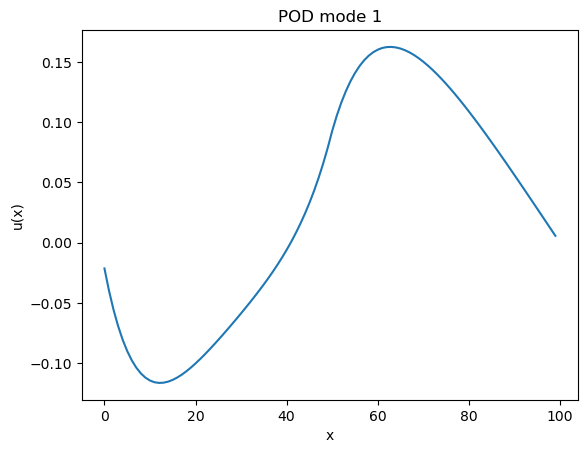

In [327]:
mode = 1
plt.plot(POD_1D[:,mode])
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title(f"POD mode {mode}")
plt.show()

In [328]:
POD_heat_equation = PDE(
            E = np.identity(size),
            A = k*Laplacian_1d(size),
            B = np.zeros((size,size)),
            x0 = x0,
            dt = .001,
            u = zerofunction,
            C = np.identity(size),

            Galerkin=True,

            V = POD_1D,

            )

In [329]:
for step in range(timesteps):
    POD_heat_equation.update()

POD_trajectory = np.asarray(POD_heat_equation.states)
POD_trajectory_reduced = np.asarray(POD_heat_equation.reduced_states)

## 2D heat eqn

In [330]:
# here, build a 2d_heat_eq = PDE(.....)
# Python variable names cannot start with a digit, so use heat_eqn_2d.
nx = 30
ny = 30
size_2d = nx * ny
dx = 1.0
dy = 1.0
k= 1.0

x0_2d_grid = np.zeros((ny, nx), dtype=np.float64)
x0_2d_grid[ny // 4: 3 * ny // 4, nx // 4: 3 * nx // 4] = 1.0
x0_2d = x0_2d_grid.reshape(-1)

def zerofunction_2d(t: float) -> NDArray[np.float64]:
    return np.zeros(size_2d, dtype=np.float64)

Lx = Laplacian_1d(nx, dx=dx)
Ly = Laplacian_1d(ny, dx=dy)
Laplacian_2d = np.kron(np.identity(ny), Lx) + np.kron(Ly, np.identity(nx))

heat_eqn_2d = PDE(
    E=np.identity(size_2d),
    A=k * Laplacian_2d,
    B=np.zeros((size_2d, size_2d)),
    C=np.identity(size_2d),
    x0=x0_2d,
    dt=0.001,
    u=zerofunction_2d,
)

In [331]:
for step in range(10**4):
    heat_eqn_2d.update()

# Visualize

## Visualize 1D

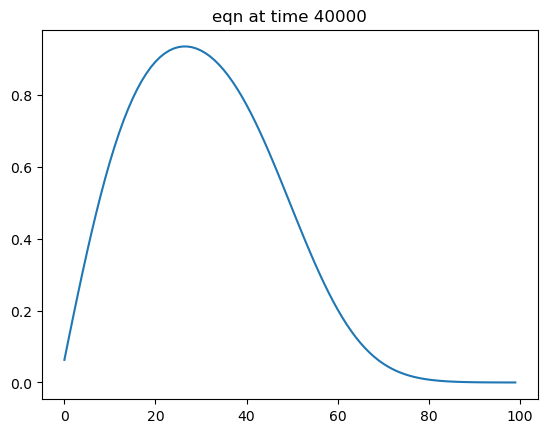

In [332]:
c=4
t = c*10**4
plt.plot(trajectory[t])
plt.title(f'eqn at time {t}')
plt.show()

In [333]:
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# x = np.arange(trajectory.shape[1])
# frames = np.arange(0, len(trajectory), 10**4) 

# fig, ax = plt.subplots()
# line, = ax.plot(x, trajectory[0])
# title = ax.set_title("")

# ax.set_xlabel("space index")
# ax.set_ylabel("state")
# ax.set_ylim(trajectory.min(), trajectory.max())

# def update(frame):
#     line.set_ydata(trajectory[frame])
#     title.set_text(f"heat eqn at step {frame}, t = {frame * heat_eqn.dt:.3f}")
#     return line, title

# anim = FuncAnimation(
#     fig,
#     update,
#     frames=frames,
#     interval=30,
#     blit=True,
# )

# plt.close(fig)
# HTML(anim.to_jshtml())


## Visualize 2D

In [334]:
trajectory_2d = np.asarray(heat_eqn_2d.states)

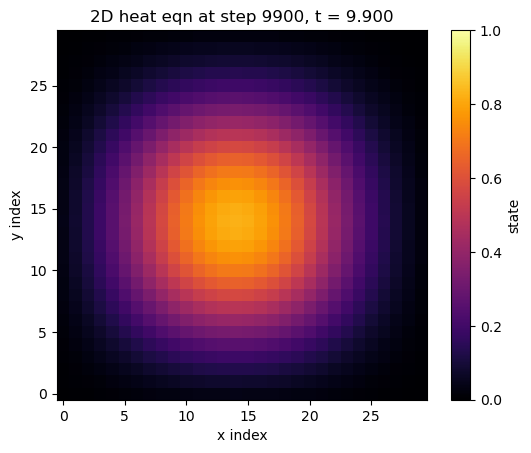

In [335]:
c = 99
t_2d = min(c * 100, len(trajectory_2d) - 1)

fig, ax = plt.subplots()
im = ax.imshow(
    trajectory_2d[t_2d].reshape(ny, nx),
    origin="lower",
    cmap="inferno",
    vmin=trajectory_2d.min(),
    vmax=trajectory_2d.max(),
)
ax.set_title(f"2D heat eqn at step {t_2d}, t = {t_2d * heat_eqn_2d.dt:.3f}")
ax.set_xlabel("x index")
ax.set_ylabel("y index")
fig.colorbar(im, ax=ax, label="state")
plt.show()

In [336]:
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# frames_2d = np.arange(0, len(trajectory_2d), 100)

# fig, ax = plt.subplots()
# im = ax.imshow(
#     trajectory_2d[0].reshape(ny, nx),
#     origin="lower",
#     cmap="inferno",
#     vmin=trajectory_2d.min(),
#     vmax=trajectory_2d.max(),
#     animated=True,
# )
# title = ax.set_title("")
# ax.set_xlabel("x index")
# ax.set_ylabel("y index")
# fig.colorbar(im, ax=ax, label="state")

# def update_2d(frame):
#     im.set_array(trajectory_2d[frame].reshape(ny, nx))
#     title.set_text(f"2D heat eqn at step {frame}, t = {frame * heat_eqn_2d.dt:.3f}")
#     return im, title

# anim_2d = FuncAnimation(
#     fig,
#     update_2d,
#     frames=frames_2d,
#     interval=30,
#     blit=True,
# )

# plt.close(fig)
# HTML(anim_2d.to_jshtml())

## Visualize POD 1D

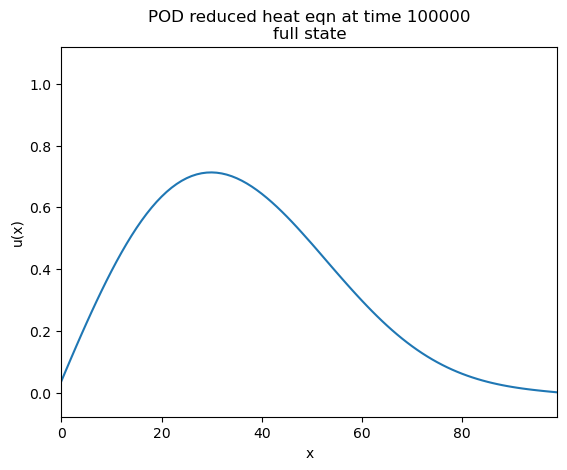

In [337]:
c = 1
t = min(c * 10**5, len(POD_trajectory) - 1)

### ADJ HERE

x = np.arange(POD_trajectory.shape[1])

fig, ax = plt.subplots()
ax.plot(x, POD_trajectory[t])
ax.set_title(f'POD reduced heat eqn at time {t}\nfull state')
ax.set_xlabel('x')
ax.set_ylabel('u(x)')
ax.set_xlim(x.min(), x.max())
ax.set_ylim(POD_trajectory.min(), POD_trajectory.max())
plt.show()


# plt.plot(POD_trajectory_reduced[t])
# plt.title(f'POD reduced heat eqn at time {t}\nreduced state')
# plt.xlabel('trial subspace coordinate')
# plt.ylabel('??')
# plt.show()

In [338]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

x = np.arange(POD_trajectory.shape[1])
frames = np.arange(0, len(POD_trajectory), 10**4) 

fig, ax = plt.subplots()
line, = ax.plot(x, POD_trajectory[0])
title = ax.set_title("")

ax.set_xlabel("space index")
ax.set_ylabel("state")
ax.set_ylim(POD_trajectory.min(), POD_trajectory.max())

def update(frame):
    line.set_ydata(POD_trajectory[frame])
    title.set_text(f"heat eqn at step {frame}, t = {frame * POD_heat_equation.dt:.3f}")
    return line, title

anim_reduced = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=30,
    blit=True,
)

plt.close(fig)
HTML(anim_reduced.to_jshtml())


## Dummy